# Dynamic Programming in Reinforcement Learning
## Policy Evaluation, Policy Improvement, and Policy Iteration

This beginner-friendly notebook turns the lecture into mathematics, intuition, Python experiments, and visualizations.

**Roadmap:** prediction problem → Bellman updates → iterative policy evaluation → policy improvement → policy iteration.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11
print("Ready!")


Ready!


# 1. Dynamic Programming

Dynamic Programming (DP) is a collection of methods for solving reinforcement-learning problems when the environment model is known.

The lecture's key objective is to move from merely **writing Bellman equations** to actually **solving value functions and improving policies**.

DP has two major ideas:

- **Prediction / Policy evaluation:** Given $\pi$, estimate $V_\pi$.
- **Control / Policy improvement:** Use values to move toward a better policy.


# 2. Policy Evaluation = Prediction

For a fixed policy $\pi$,

$$V_\pi(s)=\mathbb{E}_\pi[G_t\mid S_t=s]$$

The prediction problem asks:

> If the agent follows the given policy, what cumulative discounted reward should we expect from each state?

Policy evaluation is **not** judging whether a policy is good or bad. It specifically means computing its value function.


# 3. Bellman Expectation Equation

$$
V_\pi(s)=
\sum_a\pi(a\mid s)
\sum_{s',r}p(s',r\mid s,a)
\left[r+\gamma V_\pi(s')\right]
$$

Interpretation:

1. Consider possible actions.
2. Consider possible next states and rewards.
3. Add immediate reward $r$.
4. Add discounted future value $\gamma V_\pi(s')$.
5. Average according to policy and transition probabilities.


In [2]:
gamma=0.9
policy_probs={"A1":0.6,"A2":0.4}
reward={"A1":2.0,"A2":1.0}
next_value={"A1":8.0,"A2":12.0}

estimate=sum(policy_probs[a]*(reward[a]+gamma*next_value[a]) for a in policy_probs)
print("One-step Bellman estimate =", estimate)


One-step Bellman estimate = 10.24


# 4. Why Iteration Is Needed

The Bellman equation is recursive:

$$V_\pi(S_1)$$

depends on values of later states, and those values depend on still later states.

For $n$ states, this produces a system with:

- $n$ equations
- $n$ unknown state values

Dynamic Programming avoids solving the full system directly by repeatedly improving an estimate.


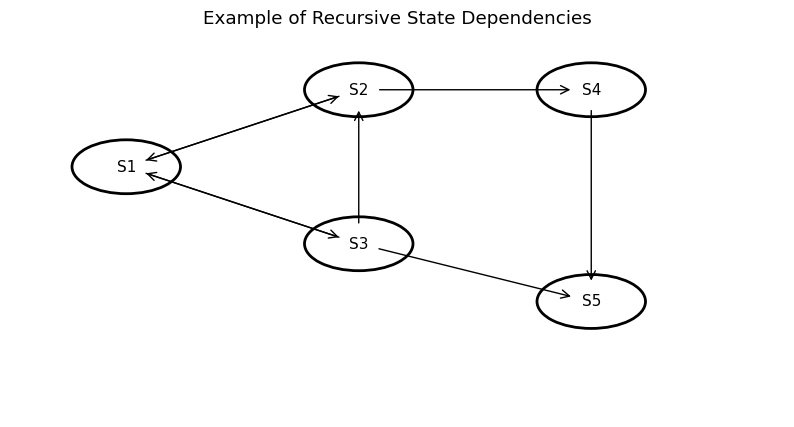

In [3]:
fig, ax=plt.subplots(figsize=(10,5))
ax.axis("off")
pos={"S1":(.15,.65),"S2":(.45,.85),"S3":(.45,.45),"S4":(.75,.85),"S5":(.75,.30)}
for s,p in pos.items():
    ax.add_patch(Circle(p,.07,fill=False,linewidth=2))
    ax.text(*p,s,ha="center",va="center")
for a,b in [("S1","S2"),("S1","S3"),("S2","S1"),("S2","S4"),("S3","S1"),("S3","S2"),("S3","S5"),("S4","S5")]:
    ax.add_patch(FancyArrowPatch(pos[a],pos[b],arrowstyle="->",mutation_scale=15,shrinkA=15,shrinkB=15))
ax.set_xlim(0,1); ax.set_ylim(0,1)
plt.title("Example of Recursive State Dependencies")
plt.show()


# 5. Iterative Policy Evaluation

Start with an initial guess, commonly:

$$V_0(s)=0$$

Then repeatedly update:

$$
V_{k+1}(s)=
\sum_a\pi(a\mid s)
\sum_{s',r}p(s',r\mid s,a)
\left[r+\gamma V_k(s')\right]
$$

The sequence

$$V_0,V_1,V_2,\ldots$$

progressively approaches the value function of the fixed policy.


# 6. Numerical Example

For a fixed Markov Reward Process:

$$V_{k+1}=r+\gamma PV_k$$

where $P$ is the transition matrix and $r$ contains expected immediate rewards.


Estimated value function: [21.78179036 22.25606982 24.59098409]


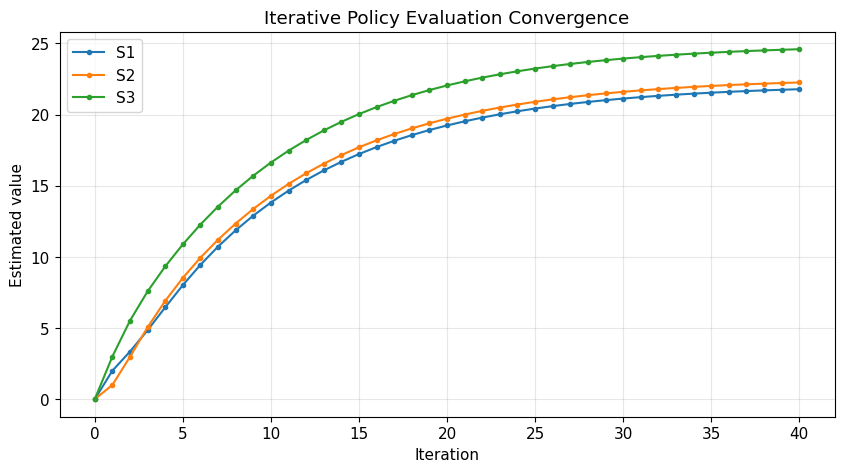

In [4]:
P=np.array([[0.5,0.5,0.0],
            [0.0,0.4,0.6],
            [0.2,0.0,0.8]])
r=np.array([2.0,1.0,3.0])
gamma=0.9

V=np.zeros(3)
history=[V.copy()]
for _ in range(40):
    V=r+gamma*P@V
    history.append(V.copy())

history=np.array(history)
print("Estimated value function:", V)

for i in range(3):
    plt.plot(history[:,i],marker="o",markersize=3,label=f"S{i+1}")
plt.xlabel("Iteration")
plt.ylabel("Estimated value")
plt.title("Iterative Policy Evaluation Convergence")
plt.legend(); plt.grid(alpha=.3); plt.show()


# 7. State Sweeps

One DP iteration updates **every state**. This is called a full state sweep.

If there are 1,000 states and 50 iterations, the algorithm performs 50,000 state updates.

This explains one computational drawback emphasized in the lecture.


In [5]:
states=1000
iterations=50
print("Total updates =", states*iterations)


Total updates = 50000


# 8. Why DP Is Not Pure Learning From Experience

DP requires a known model, especially transition probabilities:

$$p(s',r\mid s,a)$$

If an agent is placed in an unknown environment, these probabilities may not be known.

Therefore DP is model-based. The lecture uses it as a foundation before Monte Carlo and Temporal-Difference methods.


# 9. Policy Improvement

Suppose the current policy recommends action $A_1$ in state $s$.

We compare all actions using:

$$
q_\pi(s,a)=
\sum_{s',r}p(s',r\mid s,a)
[r+\gamma V_\pi(s')]
$$

Then choose:

$$
\pi'(s)=\arg\max_a q_\pi(s,a)
$$

If another action gives a larger expected return, change the policy.


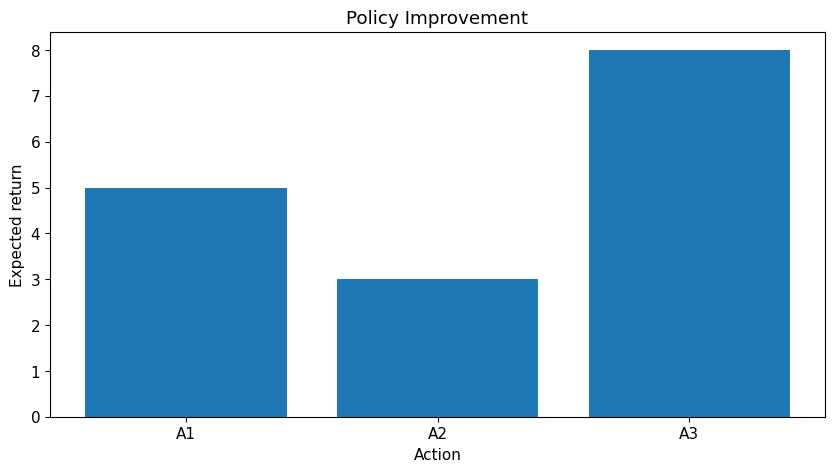

Old policy chooses A1
Improved choice: A3


In [6]:
actions=["A1","A2","A3"]
returns=np.array([5.0,3.0,8.0])
plt.bar(actions,returns)
plt.xlabel("Action"); plt.ylabel("Expected return")
plt.title("Policy Improvement")
plt.show()
print("Old policy chooses A1")
print("Improved choice:",actions[np.argmax(returns)])


# 10. Why Policy Evaluation Helps Policy Improvement

To compare actions we need:

$$r+\gamma V_\pi(s')$$

The value of the next state comes from policy evaluation.

Thus:

$$
\boxed{\text{Policy} \rightarrow \text{Evaluate values} \rightarrow \text{Improve policy}}
$$


# 11. Policy Iteration

Policy iteration repeatedly performs:

## A. Policy evaluation
Given $\pi_k$, compute $V_{\pi_k}$.

## B. Policy improvement
Use $V_{\pi_k}$ to create $\pi_{k+1}$:

$$
\pi_{k+1}(s)=
\arg\max_a
\sum_{s',r}p(s',r\mid s,a)
[r+\gamma V_{\pi_k}(s')]
$$

Repeat until the policy stops changing.


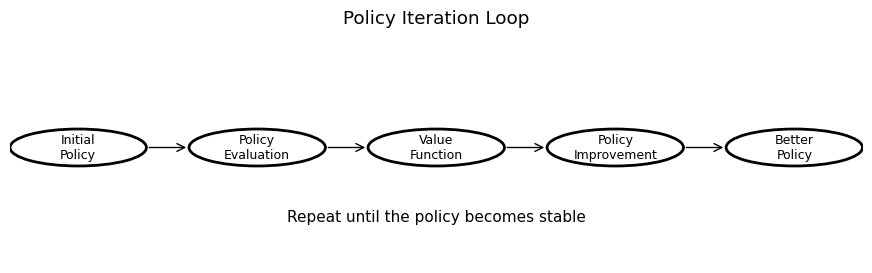

In [7]:
fig,ax=plt.subplots(figsize=(11,3))
ax.axis("off")
labels=["Initial\nPolicy","Policy\nEvaluation","Value\nFunction","Policy\nImprovement","Better\nPolicy"]
xs=np.linspace(.08,.92,len(labels))
for i,(x,label) in enumerate(zip(xs,labels)):
    ax.add_patch(Circle((x,.5),.08,fill=False,linewidth=2))
    ax.text(x,.5,label,ha="center",va="center",fontsize=9)
    if i<len(labels)-1:
        ax.add_patch(FancyArrowPatch((x+.08,.5),(xs[i+1]-.08,.5),arrowstyle="->",mutation_scale=14))
ax.text(.5,.18,"Repeat until the policy becomes stable",ha="center")
ax.set_xlim(0,1); ax.set_ylim(0,1)
plt.title("Policy Iteration Loop")
plt.show()


# 12. Implementing Policy Iteration

We now solve a small, fully known MDP.

Each transition is represented as:

`(next_state, probability, reward)`

The example is designed to show the complete evaluate → improve loop.


In [8]:
num_states=3
gamma=0.9

transitions={
0:{0:[(0,.7,1.0),(1,.3,1.0)],
   1:[(1,1.0,2.0)]},
1:{0:[(0,.5,0.0),(2,.5,4.0)],
   1:[(1,1.0,1.0)]},
2:{0:[(0,1.0,3.0)],
   1:[(2,1.0,0.0)]}
}

policy=np.zeros(num_states,dtype=int)
print("Initial policy:",policy)


Initial policy: [0 0 0]


In [9]:
def evaluate_policy(policy, transitions, gamma=.9, tolerance=1e-10, max_iterations=10000):
    V=np.zeros(len(policy))
    for _ in range(max_iterations):
        V_new=np.zeros_like(V)
        for s,a in enumerate(policy):
            V_new[s]=sum(p*(reward+gamma*V[ns]) for ns,p,reward in transitions[s][a])
        if np.max(np.abs(V_new-V))<tolerance:
            return V_new
        V=V_new
    return V

def improve_policy(V, transitions, gamma=.9):
    new_policy=np.zeros(len(V),dtype=int)
    Q=np.zeros((len(V),2))
    for s in range(len(V)):
        for a in range(2):
            Q[s,a]=sum(p*(reward+gamma*V[ns]) for ns,p,reward in transitions[s][a])
        new_policy[s]=np.argmax(Q[s])
    return new_policy,Q


In [10]:
policy=np.zeros(num_states,dtype=int)
value_history=[]

for iteration in range(20):
    V=evaluate_policy(policy,transitions,gamma)
    new_policy,Q=improve_policy(V,transitions,gamma)
    value_history.append(V.copy())
    print(f"Iteration {iteration}: policy={policy}, values={V}")
    if np.array_equal(new_policy,policy):
        print("Policy stable.")
        break
    policy=new_policy

print("\nFinal policy:",policy)
print("Final values:",V)


Iteration 0: policy=[0 0 0], values=[13.68666906 15.05210205 15.31800216]
Iteration 1: policy=[1 0 0], values=[21.75704989 21.95227766 22.5813449 ]
Policy stable.

Final policy: [1 0 0]
Final values: [21.75704989 21.95227766 22.5813449 ]


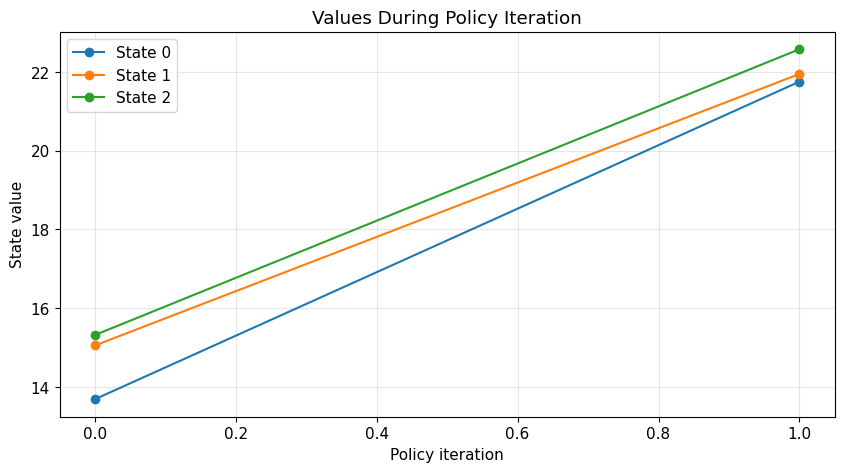

In [11]:
value_history=np.array(value_history)
for s in range(num_states):
    plt.plot(value_history[:,s],marker="o",label=f"State {s}")
plt.xlabel("Policy iteration")
plt.ylabel("State value")
plt.title("Values During Policy Iteration")
plt.legend(); plt.grid(alpha=.3); plt.show()


# 13. Final Mathematical Summary

### Policy evaluation

$$
V_{k+1}(s)=
\sum_a\pi(a|s)
\sum_{s',r}p(s',r|s,a)
[r+\gamma V_k(s')]
$$

### Action comparison

$$
q_\pi(s,a)=
\sum_{s',r}p(s',r|s,a)
[r+\gamma V_\pi(s')]
$$

### Greedy improvement

$$
\pi'(s)=\arg\max_a q_\pi(s,a)
$$

### Policy iteration

$$
\boxed{
\text{Evaluate}
\rightarrow
\text{Improve}
\rightarrow
\text{Repeat}
}
$$
